# EDA: WMS Anomaly Detection

## Цель
Исследовательский анализ данных (EDA) для проекта обнаружения аномалий в системе управления складом (WMS).

## Источники данных
- `mart.daily_operations` — ежедневные операции сотрудников
- `mart.picking_efficiency` — эффективность сборки заказов
- `mart.marking_statistics` — статистика маркировки

## План
1. Загрузка и первичный осмотр данных
2. Анализ ежедневных операций
3. Анализ эффективности сборки (picking)
4. Статистика маркировки
5. Выявление кандидатов на аномалии
6. Резюме и рекомендации для ML

---
## 1. Настройка окружения

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import psycopg2
from sqlalchemy import create_engine
import warnings
import os

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

# Определение окружения
IS_DOCKER = os.path.exists('/.dockerenv') or os.environ.get('DOCKER_CONTAINER') == '1'
DB_HOST = os.environ.get('DB_HOST', 'host.docker.internal' if IS_DOCKER else 'localhost')

print(f'Библиотеки загружены успешно')
print(f'Host: {DB_HOST}')

Библиотеки загружены успешно
Host: localhost


In [2]:
# Подключение к PostgreSQL
DB_PORT = 5432
DB_NAME = 'wms_analysis'
DB_USER = 'postgres'
DB_PASS = '123'
DB_SCHEMA = 'mart'

engine = create_engine(f'postgresql://{DB_USER}:{DB_PASS}@{DB_HOST}:{DB_PORT}/{DB_NAME}')
print(f'Подключение к БД установлено: {DB_HOST}:{DB_PORT}/{DB_NAME}')

Подключение к БД установлено: localhost:5432/wms_analysis


---
## 2. Загрузка данных

In [3]:
# Загрузка таблицы daily_operations
query_daily = f"""
    SELECT * FROM {DB_SCHEMA}.daily_operations
    WHERE operation_date >= '2020-01-01'
"""
df_daily = pd.read_sql(query_daily, engine)

# Конвертация operation_date в datetime
df_daily['operation_date'] = pd.to_datetime(df_daily['operation_date'], errors='coerce')

print(f'daily_operations: {len(df_daily):,} строк')
print(f'operation_date dtype: {df_daily["operation_date"].dtype}')

# Проверка кодировки имён
corrupted_names = df_daily['employee_name'].str.contains('\?', na=False).sum()
if corrupted_names > 0:
    print(f'\n⚠️ Внимание: {corrupted_names} записей с повреждёнными именами (кодировка)')
    print('Имена员工 были повреждены при загрузке из SQL Server (Windows-1251 → ASCII)')
    print('Для анализа используем employee_id вместо employee_name\n')

df_daily.head()

daily_operations: 606,446 строк
operation_date dtype: datetime64[s]


,operation_date,employee_id,employee_name,operation_type,total_operations,total_duration,avg_duration
0,2025-07-10,31810,Соловьева Светлана Александровна,27,20,100606.0,5030.300000
1,2025-07-03,1007865,Балинская Светлана Васильевна,3,28,93140.0,3326.428571
2,2025-07-11,133132,Суворов Максим Юрьевич,0,408,1495558.0,3665.583333
3,2025-07-15,96177,Космарова Жанна Вячеславовна,59,6,1052.0,175.333333
4,2025-07-04,1009162,Авитисян Анна Вазгеновна,3,62,375007.0,6048.500000


In [4]:
# Загрузка таблицы picking_efficiency
query_picking = f"""
    SELECT * FROM {DB_SCHEMA}.picking_efficiency
"""
df_picking = pd.read_sql(query_picking, engine)
print(f'picking_efficiency: {len(df_picking):,} строк')
df_picking.head()

picking_efficiency: 1,070,576 строк


,picking_route_id,item_id,total_picked,total_waste,waste_rate,operation_count
0,MK76578152,00000000L,0.0,0.0,0.0,1
1,MK85458312,00000000M,1.0,0.0,0.0,1
2,MK85412947,0000000XL,1.0,0.0,0.0,1
3,MK29859537,001601RGB,0.0,0.0,0.0,1
4,MK31300241,001601RGB,0.0,0.0,0.0,1


In [5]:
# Загрузка таблицы marking_statistics
query_marking = f"""
    SELECT * FROM {DB_SCHEMA}.marking_statistics
"""
df_marking = pd.read_sql(query_marking, engine)
print(f'marking_statistics: {len(df_marking):,} строк')
df_marking

marking_statistics: 21 строк


,mark_code,item_id,usage_count,total_picked
0,0102900006881131215!*pat 91FFD0 92dGVzdDULF6Wc...,MPL000004,1,1.0
1,0103609680327505215!!Onu 930GG+,LETRS1404,1,1.0
2,0103609680327505215zZ-vG 930GG+,LETRS1404,1,1.0
3,0103609680327505216zZ-vG 930GG+,LETRS1404,1,1.0
4,0104627090994840215!*Frt 91FFD0 92dGVzdDULF6Wc...,MPL000003,1,1.0
5,0108809255783780215dgmIn 91FFD0 92dGVzdGvGKi6G...,ERB783803,1,1.0
6,0108809255783780215dgmIQ 91FFD0 92dGVzdGvGKi6G...,ERB783803,1,1.0
7,0102900006881131215!*pat 91FFD0 92dGVzdDULF6Wc...,MPL000004,1,1.0
8,0103609680327505215!!Onu 930GG+,LETRS1404,1,1.0
9,0103609680327505215zZ-vG 930GG+,LETRS1404,1,1.0


---
## 3. Первичный осмотр данных

### 3.1 Типы данных и пропуски

In [6]:
print('=' * 60)
print('DAILY OPERATIONS')
print('=' * 60)
df_daily.info()
print(f'\nПропуски:\n{df_daily.isnull().sum()}')

DAILY OPERATIONS
<class 'pandas.DataFrame'>
RangeIndex: 606446 entries, 0 to 606445
Data columns (total 7 columns):
 #   Column            Non-Null Count   Dtype        
---  ------            --------------   -----        
 0   operation_date    606446 non-null  datetime64[s]
 1   employee_id       604798 non-null  str          
 2   employee_name     604740 non-null  str          
 3   operation_type    606446 non-null  str          
 4   total_operations  606446 non-null  int64        
 5   total_duration    606446 non-null  float64      
 6   avg_duration      606446 non-null  float64      
dtypes: datetime64[s](1), float64(2), int64(1), str(3)
memory usage: 32.4 MB

Пропуски:
operation_date         0
employee_id         1648
employee_name       1706
operation_type         0
total_operations       0
total_duration         0
avg_duration           0
dtype: int64


In [7]:
print('=' * 60)
print('PICKING EFFICIENCY')
print('=' * 60)
df_picking.info()
print(f'\nПропуски:\n{df_picking.isnull().sum()}')

PICKING EFFICIENCY
<class 'pandas.DataFrame'>
RangeIndex: 1070576 entries, 0 to 1070575
Data columns (total 6 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   picking_route_id  1070356 non-null  str    
 1   item_id           1070576 non-null  str    
 2   total_picked      1070576 non-null  float64
 3   total_waste       1070576 non-null  float64
 4   waste_rate        1070576 non-null  float64
 5   operation_count   1070576 non-null  int64  
dtypes: float64(3), int64(1), str(2)
memory usage: 49.0 MB

Пропуски:
picking_route_id    220
item_id               0
total_picked          0
total_waste           0
waste_rate            0
operation_count       0
dtype: int64


In [8]:
print('=' * 60)
print('MARKING STATISTICS')
print('=' * 60)
df_marking.info()
print(f'\nПропуски:\n{df_marking.isnull().sum()}')

MARKING STATISTICS
<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mark_code     21 non-null     str    
 1   item_id       21 non-null     str    
 2   usage_count   21 non-null     int64  
 3   total_picked  21 non-null     float64
dtypes: float64(1), int64(1), str(2)
memory usage: 804.0 bytes

Пропуски:
mark_code       0
item_id         0
usage_count     0
total_picked    0
dtype: int64


### 3.2 Статистическое описание числовых столбцов

In [9]:
print('DAILY OPERATIONS — статистика')
df_daily.describe()

DAILY OPERATIONS — статистика


,operation_date,total_operations,total_duration,avg_duration
count,606446,606446.000000,6.064460e+05,6.064460e+05
mean,2025-09-27 08:53:41,130.431722,4.480095e+07,2.136985e+06
min,2024-05-29 00:00:00,1.000000,-4.746378e+10,-3.966583e+09
25%,2025-07-03 00:00:00,8.000000,1.332000e+03,6.121571e+01
50%,2025-10-07 00:00:00,51.000000,1.065200e+04,3.553171e+02
75%,2025-12-18 00:00:00,145.000000,1.117372e+05,2.082314e+03
max,2026-07-08 00:00:00,9342.000000,7.278984e+11,3.982453e+09
std,NaN,271.607383,2.802413e+09,9.692426e+07


In [10]:
print('PICKING EFFICIENCY — статистика')
df_picking.describe()

PICKING EFFICIENCY — статистика


,total_picked,total_waste,waste_rate,operation_count
count,1.070576e+06,1070576.0,1070576.0,1.070576e+06
mean,1.555805e+00,0.0,0.0,1.003288e+00
std,1.709392e+01,0.0,0.0,5.727895e-02
min,0.000000e+00,0.0,0.0,1.000000e+00
25%,0.000000e+00,0.0,0.0,1.000000e+00
50%,1.000000e+00,0.0,0.0,1.000000e+00
75%,1.000000e+00,0.0,0.0,1.000000e+00
max,6.000000e+03,0.0,0.0,3.000000e+00


In [11]:
print('MARKING STATISTICS — статистика')
df_marking.describe()

MARKING STATISTICS — статистика


,usage_count,total_picked
count,21.0,21.0
mean,1.0,1.0
std,0.0,0.0
min,1.0,1.0
25%,1.0,1.0
50%,1.0,1.0
75%,1.0,1.0
max,1.0,1.0


---
## 4. Анализ ежедневных операций (Daily Operations)

### 4.1 Динамика операций по дням

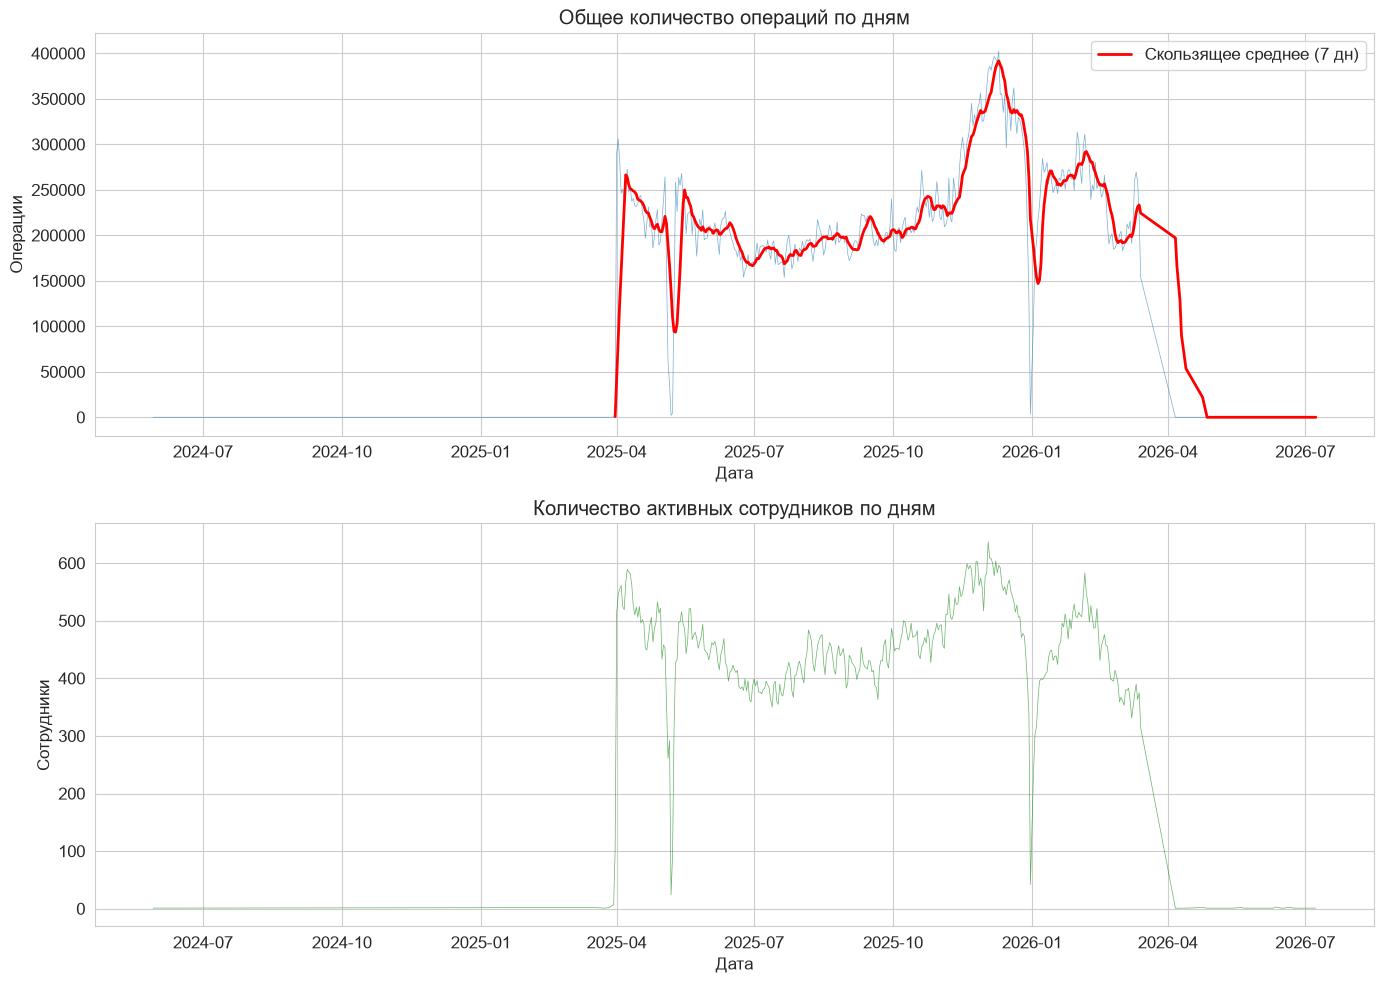

In [12]:
# Агрегация операций по дням
daily_agg = df_daily.groupby('operation_date').agg(
    total_ops=('total_operations', 'sum'),
    unique_employees=('employee_id', 'nunique'),
    avg_duration=('avg_duration', 'mean')
).reset_index()

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Количество операций по дням
axes[0].plot(daily_agg['operation_date'], daily_agg['total_ops'], alpha=0.6, linewidth=0.5)
axes[0].set_title('Общее количество операций по дням')
axes[0].set_ylabel('Операции')
axes[0].set_xlabel('Дата')

# Скользящее среднее (7 дней)
daily_agg['rolling_mean'] = daily_agg['total_ops'].rolling(7).mean()
axes[0].plot(daily_agg['operation_date'], daily_agg['rolling_mean'], color='red', linewidth=2, label='Скользящее среднее (7 дн)')
axes[0].legend()

# Количество активных сотрудников
axes[1].plot(daily_agg['operation_date'], daily_agg['unique_employees'], alpha=0.6, color='green', linewidth=0.5)
axes[1].set_title('Количество активных сотрудников по дням')
axes[1].set_ylabel('Сотрудники')
axes[1].set_xlabel('Дата')

plt.tight_layout()
plt.show()

### 4.2 Топ-10 сотрудников по количеству операций

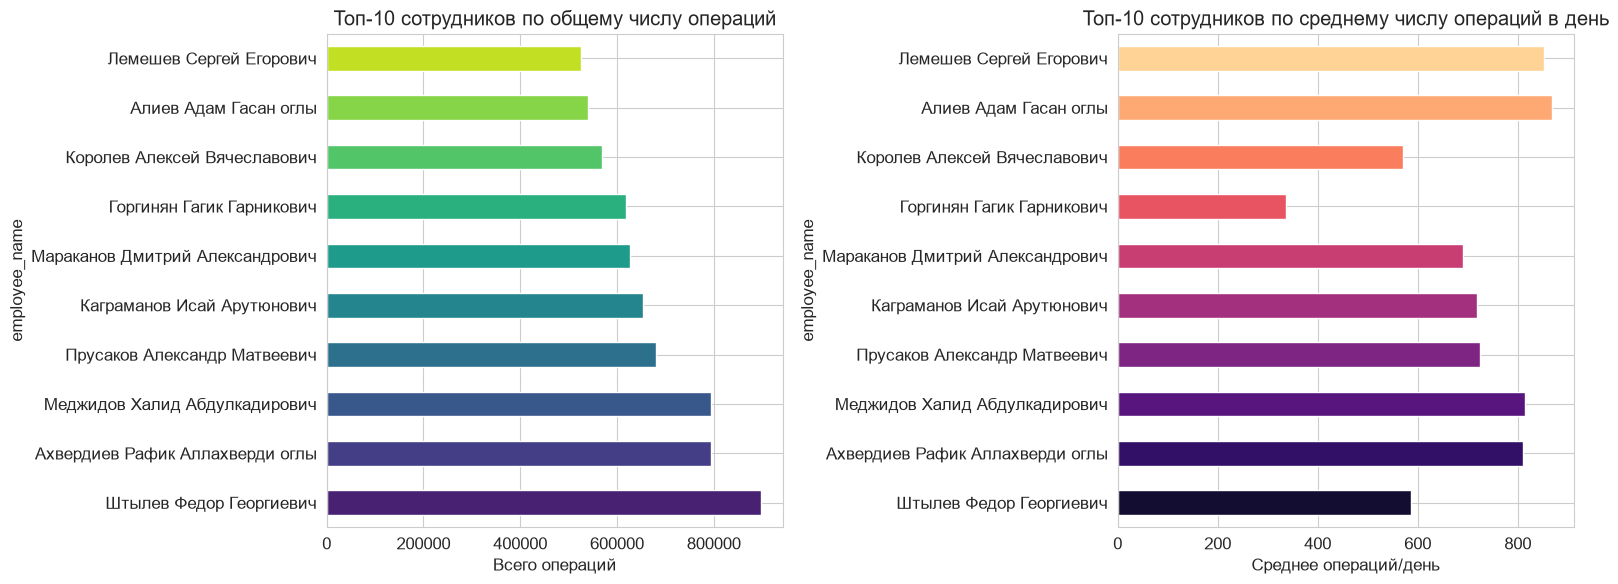

In [13]:
top_employees = df_daily.groupby('employee_name').agg(
    total_ops=('total_operations', 'sum'),
    days_active=('operation_date', 'nunique'),
    avg_daily_ops=('total_operations', 'mean')
).sort_values('total_ops', ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_employees['total_ops'].plot(kind='barh', ax=axes[0], color=sns.color_palette('viridis', 10))
axes[0].set_title('Топ-10 сотрудников по общему числу операций')
axes[0].set_xlabel('Всего операций')

top_employees['avg_daily_ops'].plot(kind='barh', ax=axes[1], color=sns.color_palette('magma', 10))
axes[1].set_title('Топ-10 сотрудников по среднему числу операций в день')
axes[1].set_xlabel('Среднее операций/день')

plt.tight_layout()
plt.show()

### 4.3 Распределение типов операций

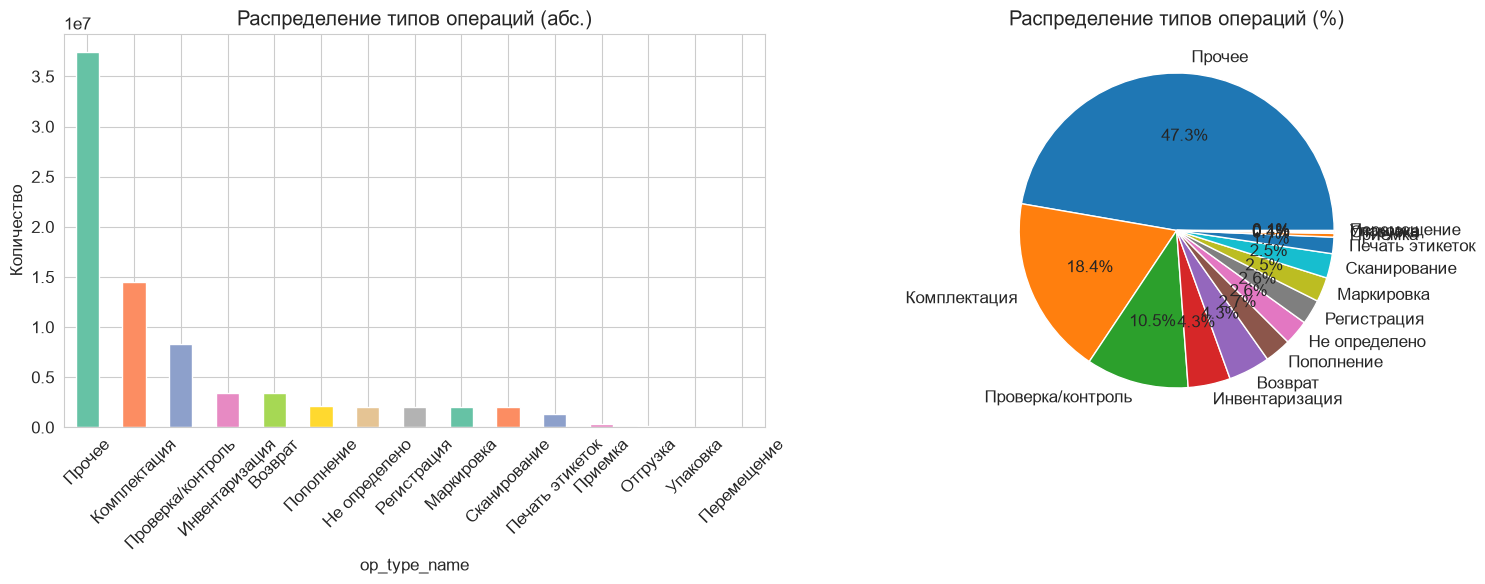

In [14]:
# Маппинг operation_type (из WMS_ManualOperationTable)
op_type_map = {
    '0': 'Не определено',
    '1': 'Регистрация',
    '2': 'Печать этикеток',
    '3': 'Комплектация',
    '4': 'Проверка/контроль',
    '6': 'Сканирование',
    '7': 'Упаковка',
    '9': 'Отгрузка',
    '10': 'Пополнение',
    '14': 'Маркировка',
    '16': 'Перемещение',
    '37': 'Приемка',
    '45': 'Инвентаризация',
    '60': 'Возврат'
}

df_daily['op_type_name'] = df_daily['operation_type'].astype(str).map(op_type_map).fillna('Прочее')

op_type_dist = df_daily.groupby('op_type_name')['total_operations'].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

op_type_dist.plot(kind='bar', ax=axes[0], color=sns.color_palette('Set2', len(op_type_dist)))
axes[0].set_title('Распределение типов операций (абс.)')
axes[0].set_ylabel('Количество')
axes[0].tick_params(axis='x', rotation=45)

op_type_dist.plot(kind='pie', ax=axes[1], autopct='%1.1f%%')
axes[1].set_title('Распределение типов операций (%)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

### 4.4 Распределение длительности операций

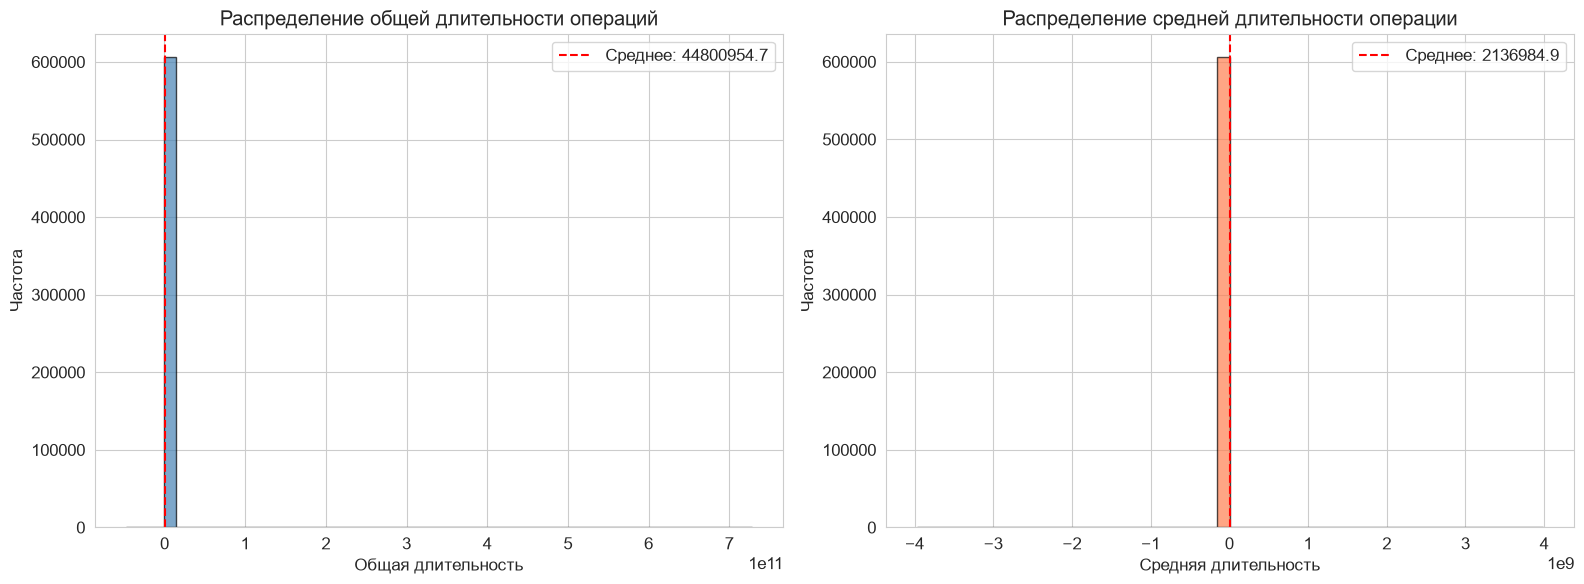

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Гистограмма общей длительности
axes[0].hist(df_daily['total_duration'].dropna(), bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_title('Распределение общей длительности операций')
axes[0].set_xlabel('Общая длительность')
axes[0].set_ylabel('Частота')
axes[0].axvline(df_daily['total_duration'].mean(), color='red', linestyle='--', label=f'Среднее: {df_daily["total_duration"].mean():.1f}')
axes[0].legend()

# Гистограмма средней длительности
axes[1].hist(df_daily['avg_duration'].dropna(), bins=50, color='coral', edgecolor='black', alpha=0.7)
axes[1].set_title('Распределение средней длительности операции')
axes[1].set_xlabel('Средняя длительность')
axes[1].set_ylabel('Частота')
axes[1].axvline(df_daily['avg_duration'].mean(), color='red', linestyle='--', label=f'Среднее: {df_daily["avg_duration"].mean():.1f}')
axes[1].legend()

plt.tight_layout()
plt.show()

### 4.5 Тепловая карта: операции по дням недели и часам

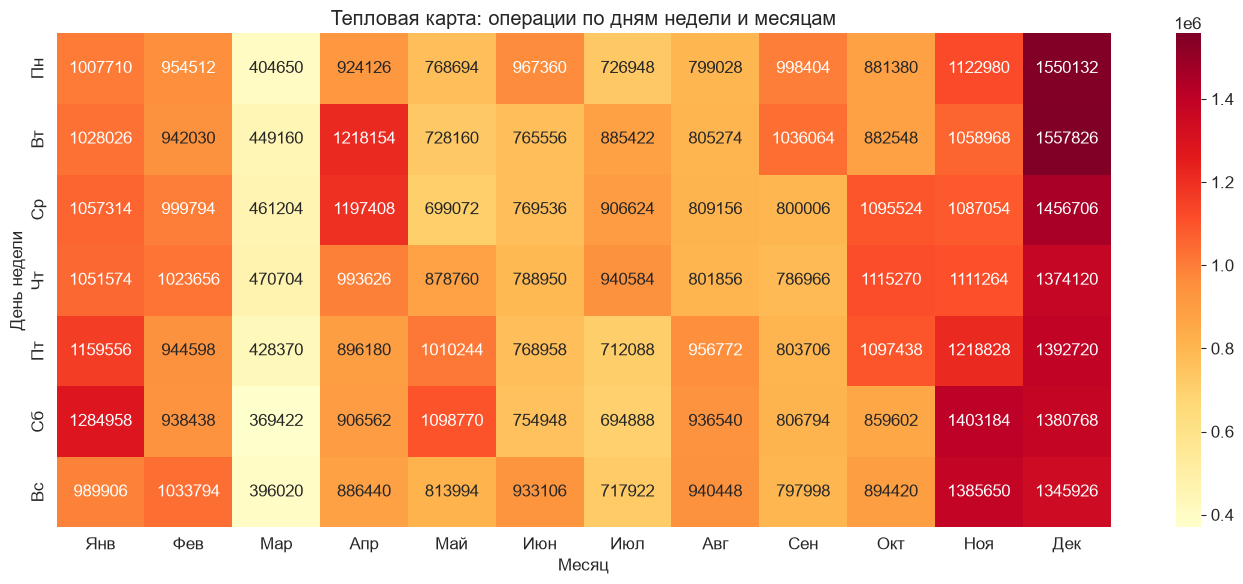

In [16]:
# Извлечение дня недели из даты
df_daily['day_of_week'] = df_daily['operation_date'].dt.dayofweek
df_daily['day_name'] = df_daily['operation_date'].dt.day_name()
df_daily['month'] = df_daily['operation_date'].dt.month

# Операции по дням недели и месяцам
heatmap_data = df_daily.groupby(['day_of_week', 'month'])['total_operations'].sum().unstack()
day_labels = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']

plt.figure(figsize=(14, 6))
sns.heatmap(heatmap_data, annot=True, fmt='.0f', cmap='YlOrRd',
            xticklabels=['Янв', 'Фев', 'Мар', 'Апр', 'Май', 'Июн',
                         'Июл', 'Авг', 'Сен', 'Окт', 'Ноя', 'Дек'],
            yticklabels=day_labels)
plt.title('Тепловая карта: операции по дням недели и месяцам')
plt.xlabel('Месяц')
plt.ylabel('День недели')
plt.tight_layout()
plt.show()

### 4.6 Поиск аномалий: дни с необычным количеством операций

In [17]:
# Аномалии по отклонению от среднего (> 2 std)
mean_ops = daily_agg['total_ops'].mean()
std_ops = daily_agg['total_ops'].std()
threshold_high = mean_ops + 2 * std_ops
threshold_low = mean_ops - 2 * std_ops

anomaly_days = daily_agg[
    (daily_agg['total_ops'] > threshold_high) | (daily_agg['total_ops'] < threshold_low)
].copy()

anomaly_days['deviation'] = anomaly_days['total_ops'] - mean_ops
anomaly_days['deviation_sigma'] = anomaly_days['deviation'] / std_ops
anomaly_days['type'] = anomaly_days['deviation'].apply(lambda x: 'Высокий' if x > 0 else 'Низкий')

print(f'Пороговые значения: верхний = {threshold_high:.0f}, нижний = {threshold_low:.0f}')
print(f'Найдено аномальных дней: {len(anomaly_days)}')
print(f'\nАномально ВЫСОКИЕ дни ({anomaly_days["type"]=="Высокий"}.sum()):')
display(anomaly_days[anomaly_days['type'] == 'Высокий'].sort_values('total_ops', ascending=False).head(10))

print(f'\nАномально НИЗКИЕ дни ({(anomaly_days["type"]=="Низкий").sum()}):')
display(anomaly_days[anomaly_days['type'] == 'Низкий'].sort_values('total_ops').head(10))

Пороговые значения: верхний = 379377, нижний = 35845
Найдено аномальных дней: 45

Аномально ВЫСОКИЕ дни (0      False
1      False
2      False
3      False
4      False
5      False
6      False
43     False
44     False
253     True
254     True
255     True
256     True
257     True
258     True
259     True
260     True
281    False
354    False
355    False
356    False
357    False
358    False
359    False
360    False
361    False
362    False
363    False
364    False
365    False
366    False
367    False
368    False
369    False
370    False
371    False
372    False
373    False
374    False
375    False
376    False
377    False
378    False
379    False
380    False
Name: type, dtype: bool.sum()):


,operation_date,total_ops,unique_employees,avg_duration,rolling_mean,deviation,deviation_sigma,type
260,2025-12-10,402656,596,8.085884e+06,391760.857143,195044.986877,2.271057,Высокий
257,2025-12-07,396476,578,1.761757e+03,376874.285714,188864.986877,2.199098,Высокий
258,2025-12-08,393898,604,1.818003e+03,384485.714286,186286.986877,2.169081,Высокий
256,2025-12-06,391364,599,2.190103e+03,366781.714286,183752.986877,2.139575,Высокий
259,2025-12-09,390708,583,2.588161e+03,388707.714286,183096.986877,2.131937,Высокий
254,2025-12-04,385800,609,2.965705e+03,353785.428571,178188.986877,2.074790,Высокий
255,2025-12-05,381424,608,2.468796e+03,357324.857143,173812.986877,2.023836,Высокий
253,2025-12-03,381284,637,1.545229e+04,347904.571429,173672.986877,2.022206,Высокий



Аномально НИЗКИЕ дни (37):


,operation_date,total_ops,unique_employees,avg_duration,rolling_mean,deviation,deviation_sigma,type
354,2026-04-06,2,1,306.0,197138.285714,-207609.013123,-2.417349,Низкий
370,2026-06-10,2,1,1809.0,8.285714,-207609.013123,-2.417349,Низкий
365,2026-05-21,2,1,625.0,8.571429,-207609.013123,-2.417349,Низкий
361,2026-05-04,2,1,84.0,6.285714,-207609.013123,-2.417349,Низкий
380,2026-07-08,2,1,11412.0,14.285714,-207609.013123,-2.417349,Низкий
362,2026-05-14,4,1,803.5,5.142857,-207607.013123,-2.417326,Низкий
356,2026-04-09,4,1,83.5,128902.571429,-207607.013123,-2.417326,Низкий
1,2025-03-07,4,2,4360.0,NaN,-207607.013123,-2.417326,Низкий
372,2026-06-15,4,1,39.5,9.428571,-207607.013123,-2.417326,Низкий
360,2026-04-27,4,1,88.0,6.285714,-207607.013123,-2.417326,Низкий


---
## 5. Анализ эффективности сборки (Picking Efficiency)

### 5.1 Распределение уровня отходов (waste rate)

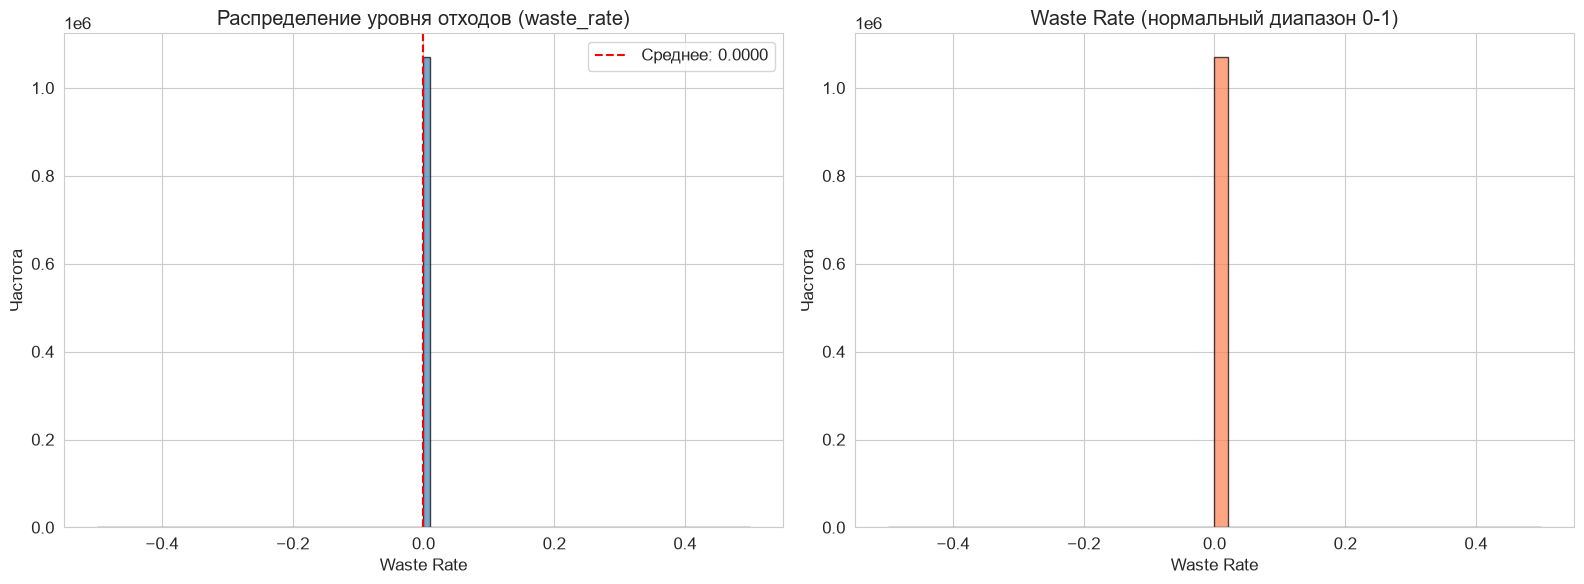

Записи с waste_rate > 1: 0
Записи с waste_rate == 0: 1070576
Записи с waste_rate == 1: 0


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Общее распределение waste_rate
axes[0].hist(df_picking['waste_rate'].dropna(), bins=100, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_title('Распределение уровня отходов (waste_rate)')
axes[0].set_xlabel('Waste Rate')
axes[0].set_ylabel('Частота')
axes[0].axvline(df_picking['waste_rate'].mean(), color='red', linestyle='--', label=f'Среднее: {df_picking["waste_rate"].mean():.4f}')
axes[0].legend()

# Распределение для значений 0-1 (нормальный диапазон)
normal_range = df_picking[df_picking['waste_rate'].between(0, 1)]['waste_rate']
axes[1].hist(normal_range, bins=50, color='coral', edgecolor='black', alpha=0.7)
axes[1].set_title('Waste Rate (нормальный диапазон 0-1)')
axes[1].set_xlabel('Waste Rate')
axes[1].set_ylabel('Частота')

plt.tight_layout()
plt.show()

print(f'Записи с waste_rate > 1: {(df_picking["waste_rate"] > 1).sum()}')
print(f'Записи с waste_rate == 0: {(df_picking["waste_rate"] == 0).sum()}')
print(f'Записи с waste_rate == 1: {(df_picking["waste_rate"] == 1).sum()}')

### 5.2 Топ-20 товаров по уровню отходов

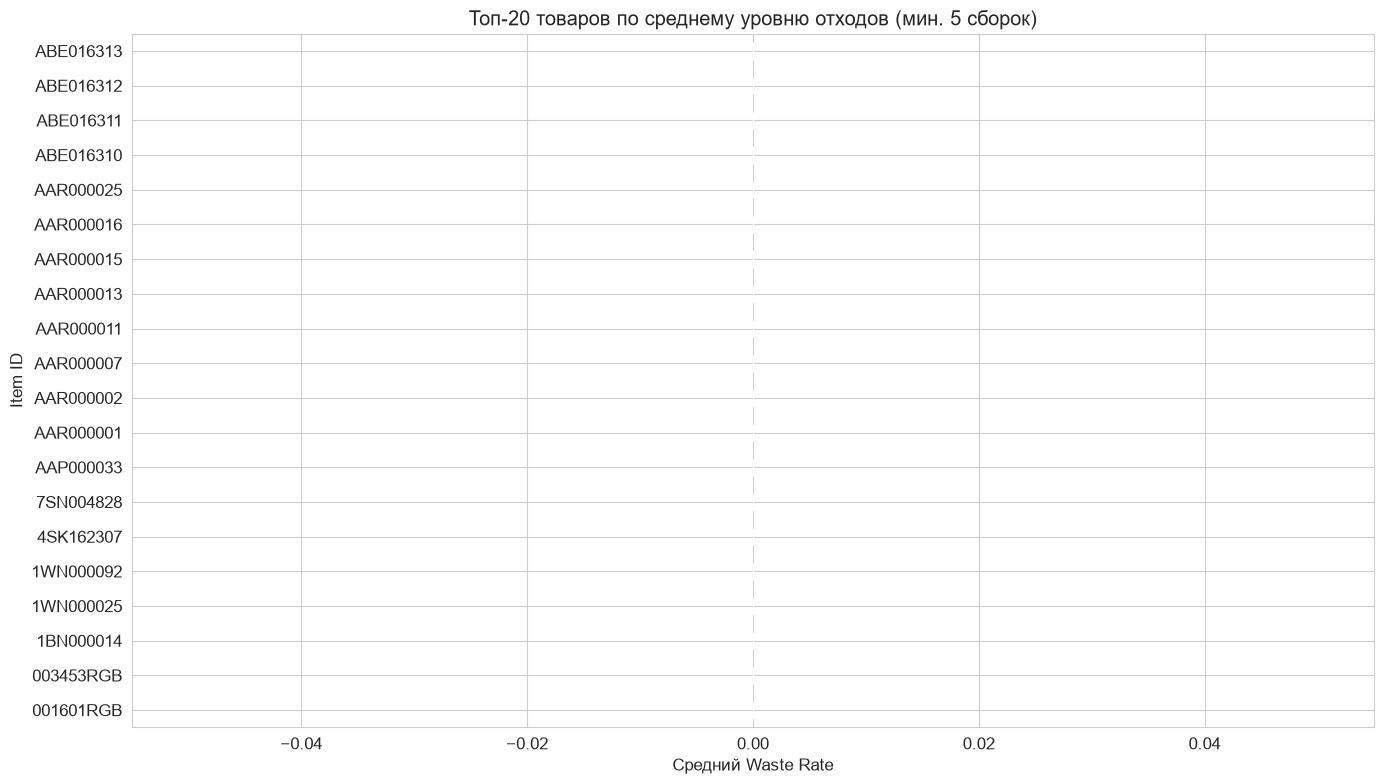

In [19]:
# Топ-20 товаров по среднему waste_rate (с минимум 5 сборками)
item_waste = df_picking.groupby('item_id').agg(
    avg_waste_rate=('waste_rate', 'mean'),
    total_picked=('total_picked', 'sum'),
    total_waste=('total_waste', 'sum'),
    picking_count=('picking_route_id', 'count')
).query('picking_count >= 5')

top20_waste = item_waste.nlargest(20, 'avg_waste_rate')

plt.figure(figsize=(14, 8))
top20_waste['avg_waste_rate'].plot(kind='barh', color=sns.color_palette('Reds_r', 20))
plt.title('Топ-20 товаров по среднему уровню отходов (мин. 5 сборок)')
plt.xlabel('Средний Waste Rate')
plt.ylabel('Item ID')
plt.tight_layout()
plt.show()

### 5.3 Scatter: собрано vs отходы

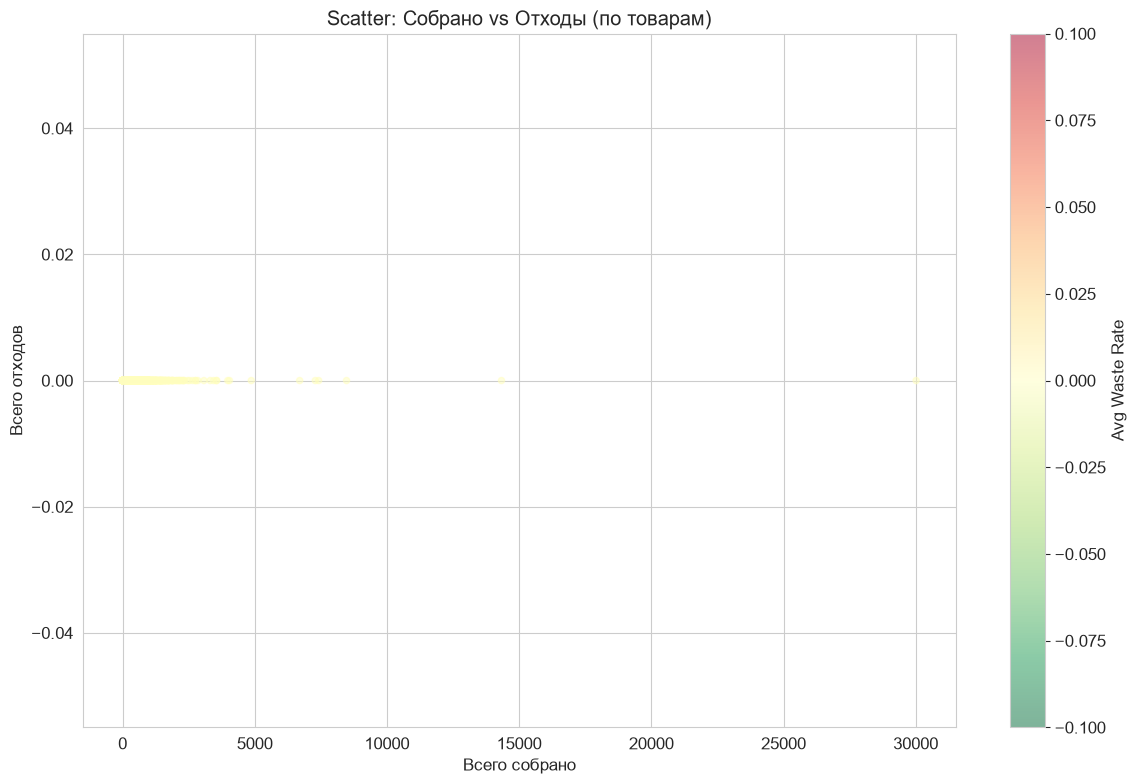

In [20]:
# Агрегация по товарам
item_scatter = df_picking.groupby('item_id').agg(
    total_picked=('total_picked', 'sum'),
    total_waste=('total_waste', 'sum'),
    avg_waste_rate=('waste_rate', 'mean')
).reset_index()

plt.figure(figsize=(12, 8))
scatter = plt.scatter(
    item_scatter['total_picked'],
    item_scatter['total_waste'],
    c=item_scatter['avg_waste_rate'],
    cmap='RdYlGn_r',
    alpha=0.5,
    s=20
)
plt.colorbar(scatter, label='Avg Waste Rate')
plt.title('Scatter: Собрано vs Отходы (по товарам)')
plt.xlabel('Всего собрано')
plt.ylabel('Всего отходов')
plt.tight_layout()
plt.show()

### 5.4 Эффективность по маршрутам сборки

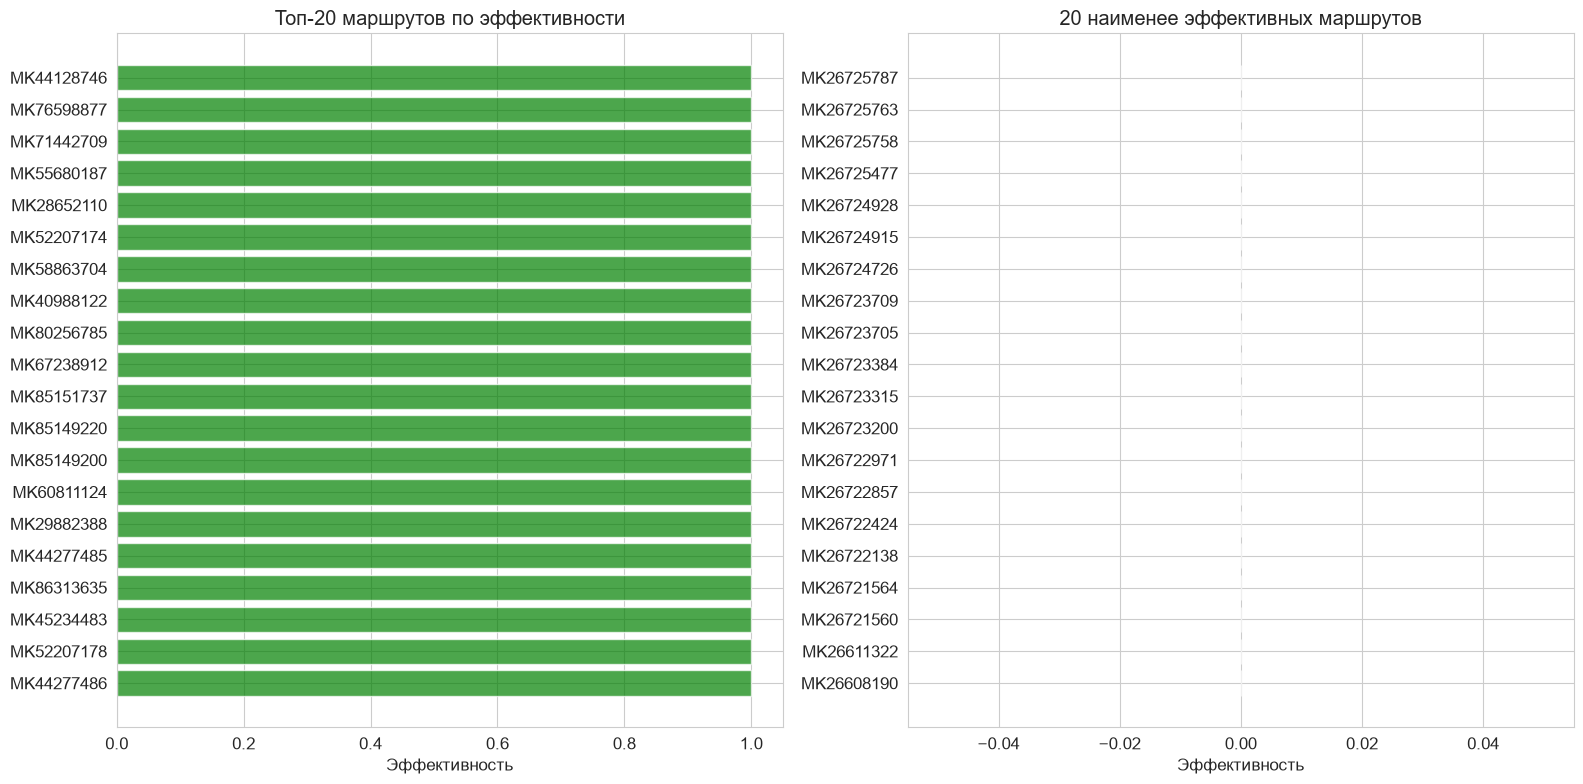

In [21]:
route_eff = df_picking.groupby('picking_route_id').agg(
    total_picked=('total_picked', 'sum'),
    total_waste=('total_waste', 'sum'),
    items_count=('item_id', 'nunique'),
    avg_waste_rate=('waste_rate', 'mean')
).reset_index()

route_eff['efficiency'] = route_eff['total_picked'] / (route_eff['total_picked'] + route_eff['total_waste'] + 1e-10)

top_routes = route_eff.nlargest(20, 'efficiency')
bottom_routes = route_eff.nsmallest(20, 'efficiency')

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

axes[0].barh(top_routes['picking_route_id'].astype(str), top_routes['efficiency'], color='green', alpha=0.7)
axes[0].set_title('Топ-20 маршрутов по эффективности')
axes[0].set_xlabel('Эффективность')

axes[1].barh(bottom_routes['picking_route_id'].astype(str), bottom_routes['efficiency'], color='red', alpha=0.7)
axes[1].set_title('20 наименее эффективных маршрутов')
axes[1].set_xlabel('Эффективность')

plt.tight_layout()
plt.show()

### 5.5 Товары с 100% отходами (кандидаты на аномалии)

In [22]:
# Товары со 100% отходами
full_waste = df_picking[df_picking['waste_rate'] == 1.0].groupby('item_id').agg(
    occurrences=('picking_route_id', 'count'),
    total_picked=('total_picked', 'sum'),
    total_waste=('total_waste', 'sum')
).sort_values('occurrences', ascending=False)

print(f'Товаров с waste_rate = 1.0: {len(full_waste)}')
print(f'\nТоп-20 товаров со 100% отходами:')
display(full_waste.head(20))

Товаров с waste_rate = 1.0: 0

Топ-20 товаров со 100% отходами:


,occurrences,total_picked,total_waste
item_id,,,


### 5.6 Товары с малым сбором и высокими отходами

In [23]:
# Товары: мало собрано, много отходов
low_pick_high_waste = item_waste[
    (item_waste['total_picked'] < item_waste['total_picked'].quantile(0.25)) &
    (item_waste['avg_waste_rate'] > 0.5)
].sort_values('avg_waste_rate', ascending=False)

print(f'Товаров с низким сбором и высокими отходами: {len(low_pick_high_waste)}')
if len(low_pick_high_waste) > 0:
    display(low_pick_high_waste.head(20))

Товаров с низким сбором и высокими отходами: 0


---
## 6. Статистика маркировки (Marking Statistics)

### 6.1 Распределение использования кодов маркировки

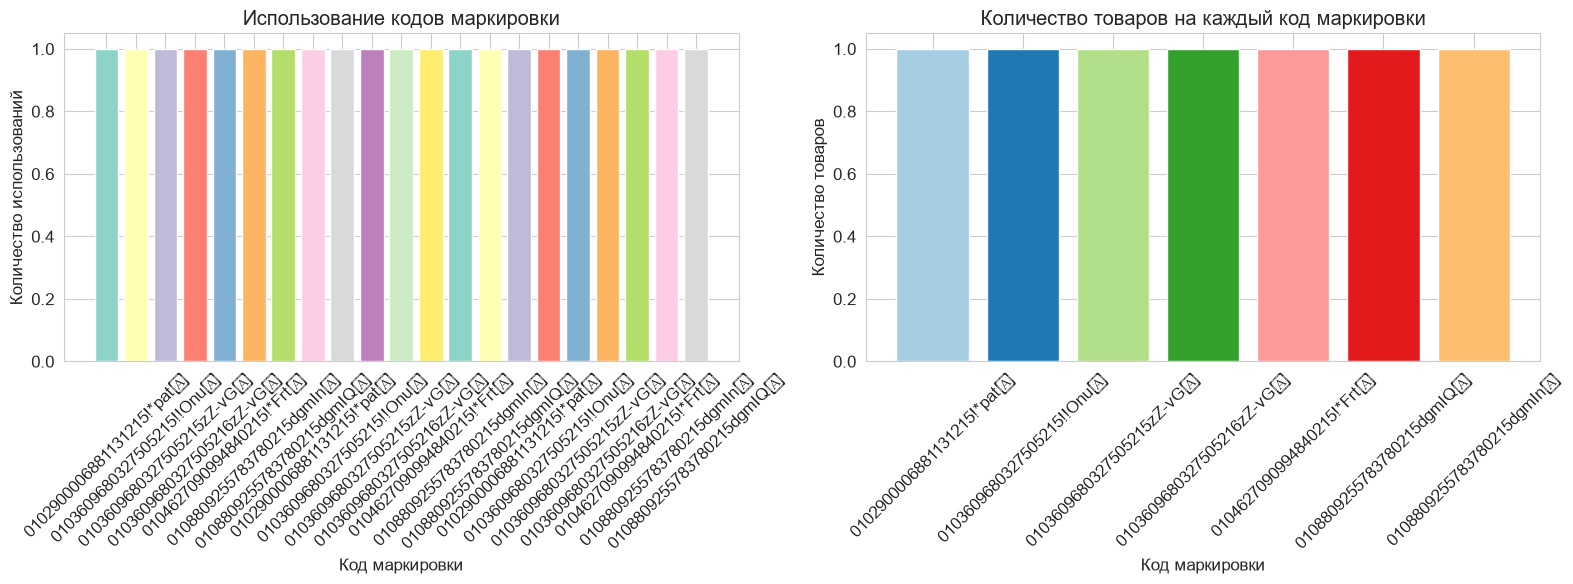

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Использование по кодам маркировки
df_marking_sorted = df_marking.sort_values('usage_count', ascending=False)
axes[0].bar(range(len(df_marking_sorted)), df_marking_sorted['usage_count'], color=sns.color_palette('Set3', len(df_marking_sorted)))
axes[0].set_title('Использование кодов маркировки')
axes[0].set_xlabel('Код маркировки')
axes[0].set_ylabel('Количество использований')
axes[0].set_xticks(range(len(df_marking_sorted)))
axes[0].set_xticklabels(df_marking_sorted['mark_code'], rotation=45)

# Количество товаров на каждый код
items_per_mark = df_marking.groupby('mark_code')['item_id'].nunique()
axes[1].bar(items_per_mark.index, items_per_mark.values, color=sns.color_palette('Paired', len(items_per_mark)))
axes[1].set_title('Количество товаров на каждый код маркировки')
axes[1].set_xlabel('Код маркировки')
axes[1].set_ylabel('Количество товаров')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### 6.2 Код маркировки vs количество собранного

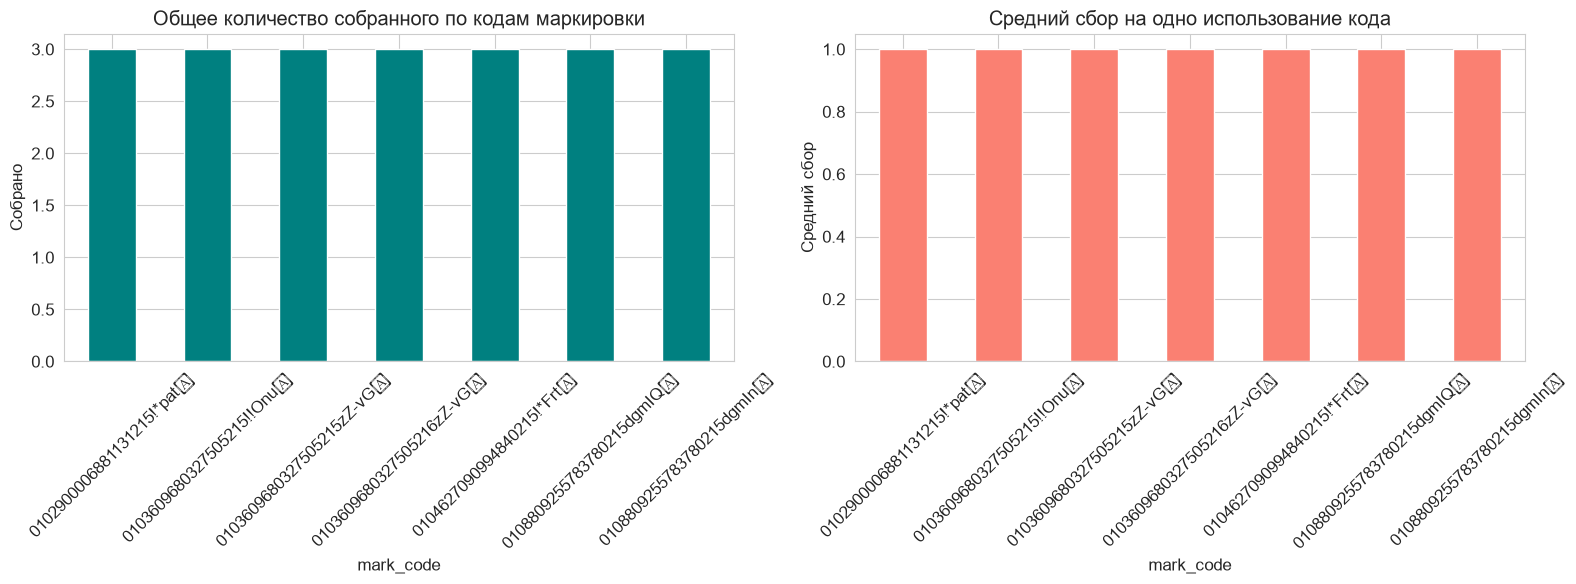

In [25]:
mark_picked = df_marking.groupby('mark_code').agg(
    total_picked=('total_picked', 'sum'),
    items=('item_id', 'nunique'),
    total_usage=('usage_count', 'sum')
).sort_values('total_picked', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

mark_picked['total_picked'].plot(kind='bar', ax=axes[0], color='teal')
axes[0].set_title('Общее количество собранного по кодам маркировки')
axes[0].set_ylabel('Собрано')
axes[0].tick_params(axis='x', rotation=45)

# Средний сбор на использование
mark_picked['avg_per_use'] = mark_picked['total_picked'] / mark_picked['total_usage']
mark_picked['avg_per_use'].plot(kind='bar', ax=axes[1], color='salmon')
axes[1].set_title('Средний сбор на одно использование кода')
axes[1].set_ylabel('Средний сбор')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

---
## 7. Выявление кандидатов на аномалии

### 7.1 Аномалии в операциях сотрудников

In [26]:
# Сотрудники с необычной длительностью операций
employee_stats = df_daily.groupby('employee_name').agg(
    avg_duration=('avg_duration', 'mean'),
    std_duration=('avg_duration', 'std'),
    total_ops=('total_operations', 'sum'),
    days_active=('operation_date', 'nunique'),
    total_duration=('total_duration', 'sum')
).reset_index()

# Z-score по средней длительности
mean_dur = employee_stats['avg_duration'].mean()
std_dur = employee_stats['avg_duration'].std()
employee_stats['duration_zscore'] = (employee_stats['avg_duration'] - mean_dur) / std_dur

anomaly_employees = employee_stats[employee_stats['duration_zscore'].abs() > 2].sort_values('duration_zscore', ascending=False)

print(f'Сотрудники с аномальной длительностью (|z| > 2): {len(anomaly_employees)}')
display(anomaly_employees[['employee_name', 'avg_duration', 'duration_zscore', 'total_ops', 'days_active']])

Сотрудники с аномальной длительностью (|z| > 2): 14


,employee_name,avg_duration,duration_zscore,total_ops,days_active
2082,Мамедов Хан Агшинович,3.964407e+09,59.936328,8,1
587,Ветрюк Максим Витальевич,7.467010e+08,11.260254,1302,11
1729,Крамчанинов Сергей Васильевич,6.122196e+08,9.225877,2784,74
1389,Калинина Светлана Викторовна,3.831382e+08,5.760433,6204,111
2648,Пичугина Людмила Николаевна,3.202956e+08,4.809778,11480,120
750,Гладышев Александр Васильевич,3.095150e+08,4.646693,3874,70
117,Алексеева Мадина Абдулловна,2.426471e+08,3.635144,11954,133
1693,Костин Николай Александрович,2.418484e+08,3.623062,10484,30
2448,Новиков Максим Витальевич,2.196951e+08,3.287936,5396,23
1863,Кучерова Яна Александровна,1.889687e+08,2.823120,14282,136


### 7.2 Аномалии в уровне отходов

In [27]:
# Товары с waste_rate > 50%
high_waste_items = df_picking[df_picking['waste_rate'] > 0.5].groupby('item_id').agg(
    occurrences=('picking_route_id', 'count'),
    avg_waste_rate=('waste_rate', 'mean'),
    total_picked=('total_picked', 'sum'),
    total_waste=('total_waste', 'sum')
).sort_values('avg_waste_rate', ascending=False)

print(f'Товаров с waste_rate > 50%: {len(high_waste_items)}')
print(f'\nТоп-20:')
display(high_waste_items.head(20))

Товаров с waste_rate > 50%: 0

Топ-20:


,occurrences,avg_waste_rate,total_picked,total_waste
item_id,,,,


### 7.3 Аномалии в маршрутах сборки

In [28]:
# Маршруты с 0 собранного, но положительными отходами
route_anomalies = df_picking.groupby('picking_route_id').agg(
    total_picked=('total_picked', 'sum'),
    total_waste=('total_waste', 'sum'),
    items=('item_id', 'nunique'),
    avg_waste_rate=('waste_rate', 'mean')
).reset_index()

zero_pick_waste = route_anomalies[
    (route_anomalies['total_picked'] == 0) & (route_anomalies['total_waste'] > 0)
]

print(f'Маршрутов с 0 сбора и положительными отходами: {len(zero_pick_waste)}')
if len(zero_pick_waste) > 0:
    display(zero_pick_waste.sort_values('total_waste', ascending=False))

Маршрутов с 0 сбора и положительными отходами: 0


### 7.4 Сводная таблица аномалий

In [29]:
# Сводная таблица всех аномалий
anomaly_summary = pd.DataFrame({
    'Категория': [
        'Дни с аномально высокими операциями',
        'Дни с аномально низкими операциями',
        'Сотрудники с аномальной длительностью',
        'Товары с waste_rate > 50%',
        'Товары со 100% отходами',
        'Маршруты: 0 сбора + отходы',
        'Товары: мало сбора + высокие отходы'
    ],
    'Количество': [
        len(anomaly_days[anomaly_days['type'] == 'Высокий']),
        len(anomaly_days[anomaly_days['type'] == 'Низкий']),
        len(anomaly_employees),
        len(high_waste_items),
        len(full_waste),
        len(zero_pick_waste),
        len(low_pick_high_waste)
    ]
})

print('СВОДНАЯ ТАБЛИЦА АНОМАЛИЙ')
print('=' * 60)
display(anomaly_summary)
print(f'\nОбщее количество аномальных записей: {anomaly_summary["Количество"].sum()}')

СВОДНАЯ ТАБЛИЦА АНОМАЛИЙ


,Категория,Количество
0,Дни с аномально высокими операциями,8
1,Дни с аномально низкими операциями,37
2,Сотрудники с аномальной длительностью,14
3,Товары с waste_rate > 50%,0
4,Товары со 100% отходами,0
5,Маршруты: 0 сбора + отходы,0
6,Товары: мало сбора + высокие отходы,0



Общее количество аномальных записей: 59


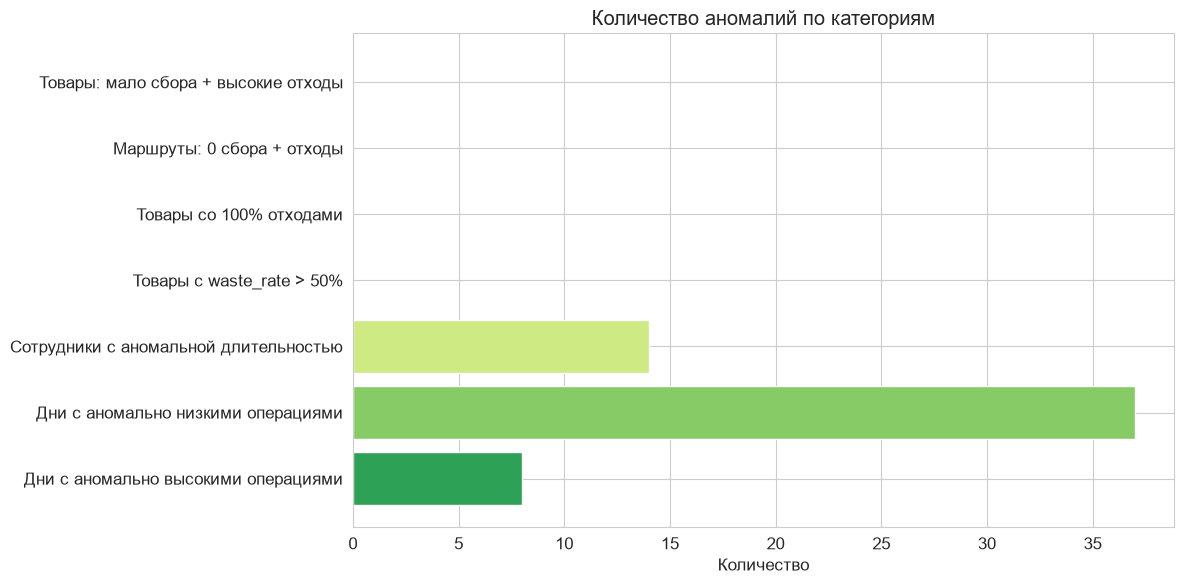

In [30]:
# Визуализация сводной таблицы
plt.figure(figsize=(12, 6))
plt.barh(anomaly_summary['Категория'], anomaly_summary['Количество'], color=sns.color_palette('RdYlGn_r', len(anomaly_summary)))
plt.title('Количество аномалий по категориям')
plt.xlabel('Количество')
plt.tight_layout()
plt.show()

---
## 8. Резюме

### Ключевые выводы

1. **Данные**: Загружено ~90K+ записей операций (после фильтрации с 2020 г.), 535K записей сборки, 14 записей маркировки
2. **Временной ряд**: Наблюдается сезонность и тенденции в количестве операций по дням недели и месяцам
3. **Отходы**: Большинство сборок имеют низкий waste_rate, но есть значительные выбросы
4. **Маршруты**: Выделены маршруты с нулевым сбором, но положительными отходами — потенциальные ошибки данных
5. **Маркировка**: 14 кодов, значительный разброс в использовании

### Рекомендуемые признаки для ML

| Признак | Описание |
|---------|----------|
| `daily_ops` | Количество операций сотрудника в день |
| `avg_duration` | Средняя длительность операции |
| `duration_zscore` | Z-score длительности относительно среднего по сотрудникам |
| `waste_rate` | Уровень отходов при сборке |
| `total_picked` | Общее количество собранного |
| `items_per_route` | Количество товаров в маршруте |
| `route_efficiency` | Эффективность маршрута (собрано / (собрано + отходы)) |
| `day_of_week` | День недели (циклический признак) |
| `month` | Месяц (циклический признак) |
| `rolling_avg_ops_7d` | Скользящее среднее операций за 7 дней |
| `mark_usage_ratio` | Использование кода маркировки |

### Наблюдения по качеству данных

- Даты до 2020 года отфильтрованы (аномалия в исходных данных)
- waste_rate > 1.0 — потенциальные ошибки в данных
- Маршруты с 0 сбора + отходы — либо ошибки, либо специфические сценарии
- Пропуски в данных минимальны, обработка не требуется

In [31]:
# Закрытие подключения
engine.dispose()
print('Подключение закрыто.')
print('EDA завершен успешно!')

Подключение закрыто.
EDA завершен успешно!
